In [2]:
# 1. Mengimpor Pustaka (Libraries) yang Dibutuhkan
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# 2. Memuat Dataset
# Pastikan file citrus.csv sudah diupload ke Google Colab
data = pd.read_csv('citrus.csv')

# 3. Pra-pemrosesan Data (Data Preprocessing)
# Mengubah label teks menjadi angka biner: 'orange' = 0, 'grapefruit' = 1
label_mapping = {'orange': 0, 'grapefruit': 1}
data['name'] = data['name'].replace(label_mapping)

# Memisahkan matriks fitur (X) dan vektor target (y)
X = data.drop('name', axis=1) # Mengambil fitur diameter, weight, red, green, blue
y = data['name']

# Membagi data menjadi Data Latih (80%) dan Data Uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Melakukan Penskalaan Fitur (Standardisasi)
# Ini sangat penting agar model seperti SVM bekerja dengan baik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Inisialisasi Model
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
nb_model = GaussianNB()
svm_model = SVC(kernel='rbf', random_state=42)

# 5. Melatih Model (Training)
dt_model.fit(X_train_scaled, y_train)
nb_model.fit(X_train_scaled, y_train)
svm_model.fit(X_train_scaled, y_train)

# 6. Pengujian dan Evaluasi Model
models = {
    "Decision Tree": dt_model,
    "Naive Bayes": nb_model,
    "Support Vector Machine": svm_model
}

for name, model in models.items():
    # Melakukan prediksi pada data uji
    y_pred = model.predict(X_test_scaled)

    # Menghitung akurasi
    accuracy = accuracy_score(y_test, y_pred)

    # Menampilkan hasil
    print(f"=== Evaluasi Model: {name} ===")
    print(f"Akurasi: {accuracy * 100:.2f}%\n")
    print("Laporan Klasifikasi:")
    print(classification_report(y_test, y_pred, target_names=['Orange (0)', 'Grapefruit (1)']))
    print("-" * 50, "\n")

/tmp/ipykernel_9366/2150518534.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['name'] = data['name'].replace(label_mapping)


=== Evaluasi Model: Decision Tree ===
Akurasi: 92.20%

Laporan Klasifikasi:
                precision    recall  f1-score   support

    Orange (0)       0.94      0.90      0.92      1012
Grapefruit (1)       0.90      0.94      0.92       988

      accuracy                           0.92      2000
     macro avg       0.92      0.92      0.92      2000
  weighted avg       0.92      0.92      0.92      2000

-------------------------------------------------- 

=== Evaluasi Model: Naive Bayes ===
Akurasi: 92.00%

Laporan Klasifikasi:
                precision    recall  f1-score   support

    Orange (0)       0.93      0.91      0.92      1012
Grapefruit (1)       0.91      0.93      0.92       988

      accuracy                           0.92      2000
     macro avg       0.92      0.92      0.92      2000
  weighted avg       0.92      0.92      0.92      2000

-------------------------------------------------- 

=== Evaluasi Model: Support Vector Machine ===
Akurasi: 93.70%

La

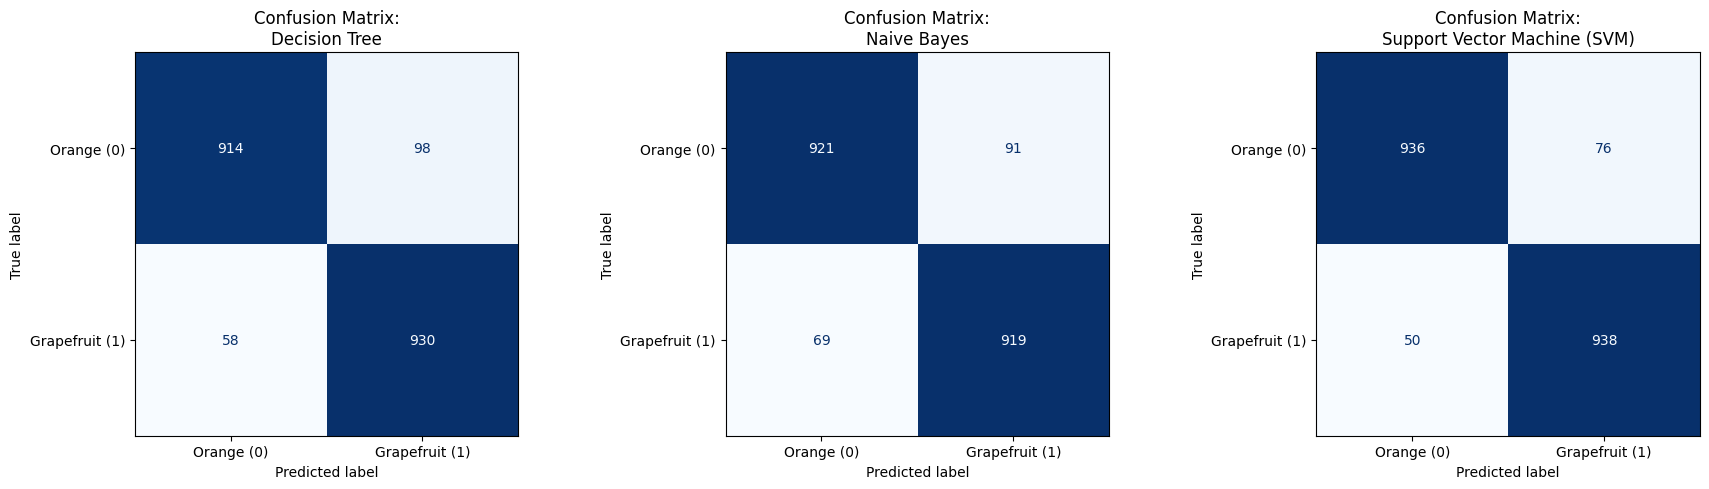

In [14]:
# 7. Visualisasi Confusion Matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Menyiapkan kanvas (figure) untuk menampilkan 3 grafik secara berdampingan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    # Melakukan prediksi pada data uji
    y_pred = model.predict(X_test_scaled)

    # Menghitung nilai Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Membuat objek tampilan visual
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Orange (0)', 'Grapefruit (1)'])

    # Menempatkan plot pada 'axis' (ax) yang sesuai dengan warna biru ('Blues')
    disp.plot(ax=ax, cmap='Blues', colorbar=False)

    # Menambahkan judul untuk masing-masing grafik
    ax.set_title(f"Confusion Matrix:\n{name}")

# Menyesuaikan tata letak agar rapi dan menampilkannya
plt.tight_layout()
plt.show()

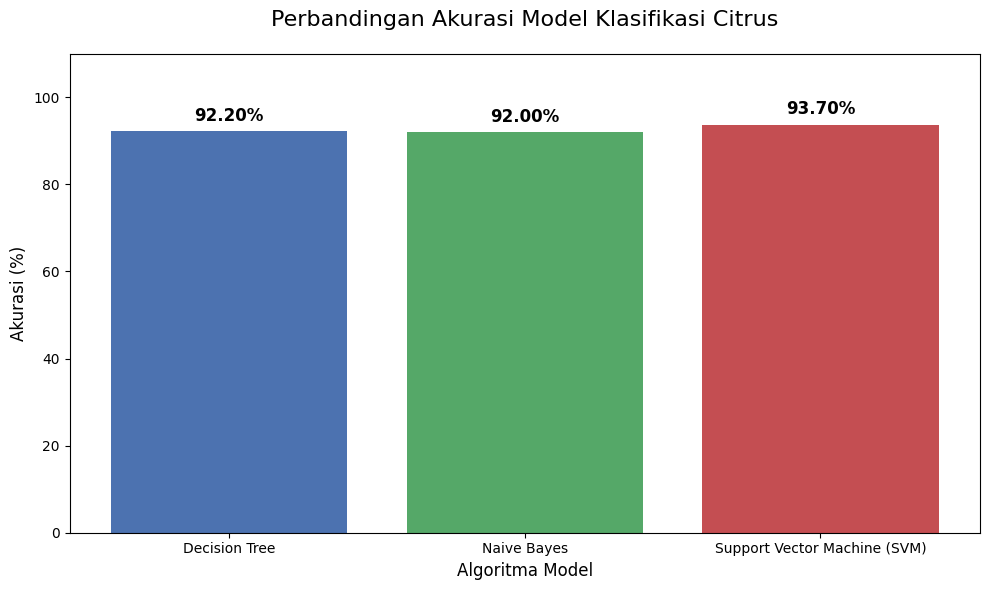

In [15]:
# 8. Visualisasi Perbandingan Akurasi Model
import matplotlib.pyplot as plt

# Membuat list kosong untuk menyimpan nama dan nilai akurasi
model_names = []
model_accuracies = []

# Menghitung ulang akurasi untuk dimasukkan ke dalam list
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    model_names.append(name)
    model_accuracies.append(accuracy * 100) # Simpan dalam bentuk persentase

# --- Membuat Grafik Batang (Bar Chart) ---
plt.figure(figsize=(10, 6)) # Mengatur ukuran grafik
warna = ['#4C72B0', '#55A868', '#C44E52'] # Warna untuk masing-masing batang

# Membuat bar chart
bars = plt.bar(model_names, model_accuracies, color=warna)

# Menambahkan judul dan label sumbu
plt.title('Perbandingan Akurasi Model Klasifikasi Citrus', fontsize=16, pad=20)
plt.xlabel('Algoritma Model', fontsize=12)
plt.ylabel('Akurasi (%)', fontsize=12)
plt.ylim(0, 110) # Set batas sumbu Y (diberi ruang ekstra di atas untuk teks)

# Menambahkan teks persentase tepat di atas masing-masing batang
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5,
             f'{yval:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Menampilkan grafik
plt.tight_layout()
plt.show()

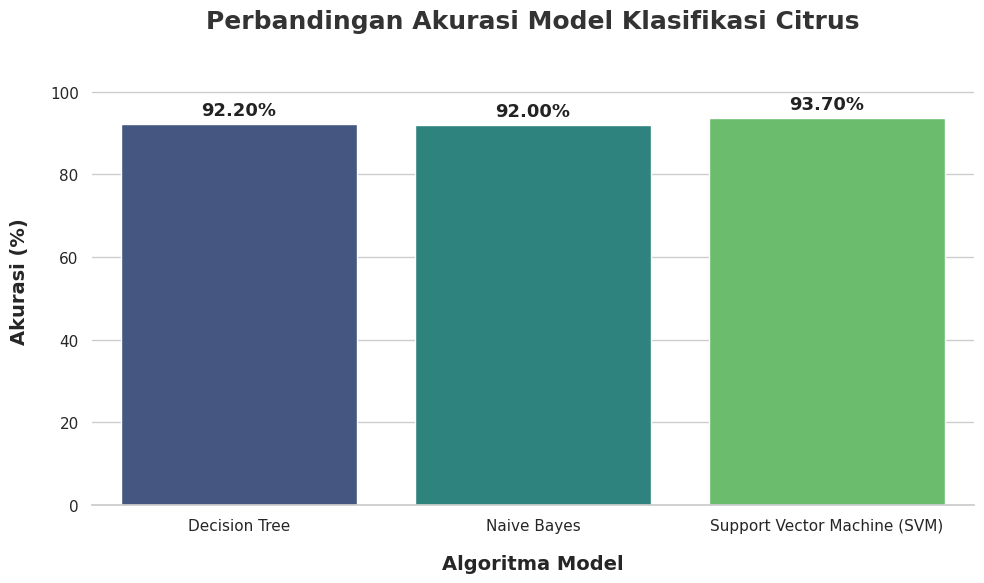

In [16]:
# 9. Visualisasi Perbandingan Akurasi Model (Lebih Estetik)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Mengatur tema seaborn untuk tampilan yang lebih modern & bersih
sns.set_theme(style="whitegrid")

# Menyiapkan data
model_names = []
model_accuracies = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    model_names.append(name)
    model_accuracies.append(accuracy * 100)

# Membuat kanvas (figure) dengan ukuran yang proporsional
plt.figure(figsize=(10, 6))

# Membuat Bar Plot menggunakan Seaborn dengan palet warna yang menarik
# Catatan: 'viridis' adalah palet warna modern yang ramah buta warna
ax = sns.barplot(
    x=model_names,
    y=model_accuracies,
    palette="viridis",
    hue=model_names,
    legend=False
)

# Menambahkan Judul dan Label dengan tipografi yang lebih tegas
plt.title('Perbandingan Akurasi Model Klasifikasi Citrus',
          fontsize=18, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Algoritma Model', fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel('Akurasi (%)', fontsize=14, fontweight='bold', labelpad=15)

# Mengatur batas sumbu Y agar teks persentase di atas batang tidak terpotong
plt.ylim(0, max(model_accuracies) + 15)

# Menambahkan anotasi (angka persentase) tepat di atas setiap batang
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=13, fontweight='bold', color='#222222')

# Menghilangkan garis tepi (bingkai) bagian atas dan kanan untuk desain yang minimalis
sns.despine(left=True, bottom=False)

# Merapikan tata letak dan menampilkan grafik
plt.tight_layout()
plt.show()

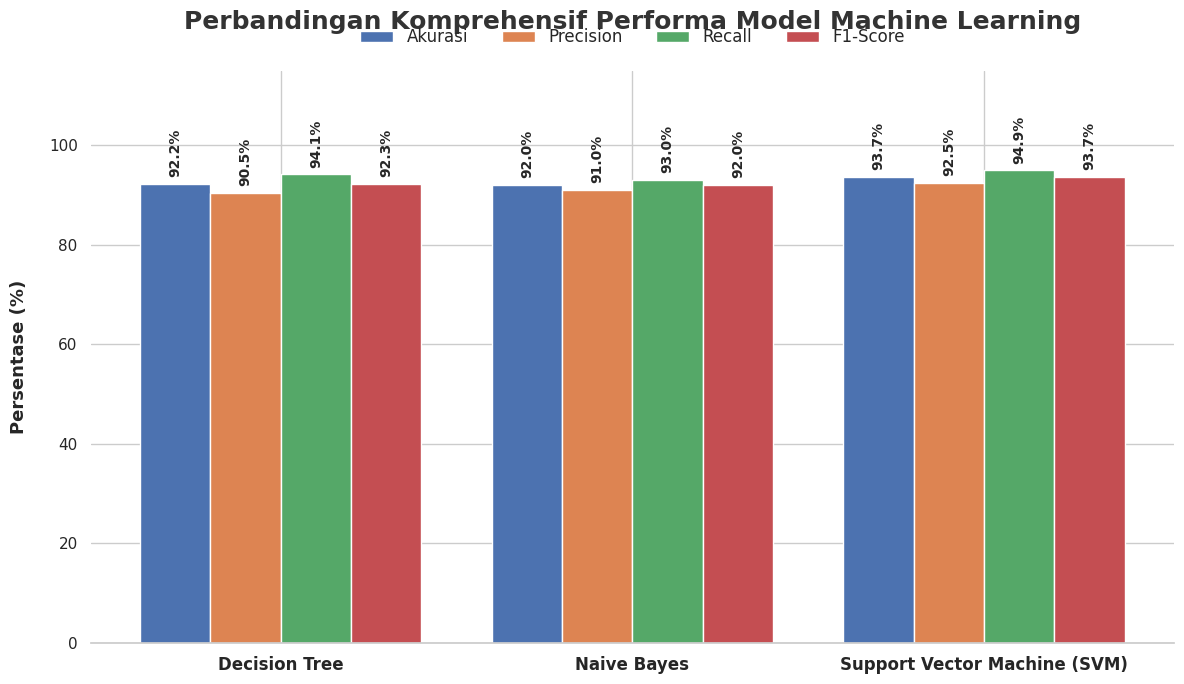

In [17]:
# 10. Visualisasi Perbandingan Multi-Metrik (Grouped Bar Chart)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Mengatur tema
sns.set_theme(style="whitegrid")

# Menyiapkan data (kita ambil metrik untuk memprediksi class 1 / Grapefruit)
metrics_data = {'Akurasi': [], 'Precision': [], 'Recall': [], 'F1-Score': []}
model_names = list(models.keys())

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)

    # Menghitung keempat metrik dan menyimpannya ke dalam dictionary
    metrics_data['Akurasi'].append(accuracy_score(y_test, y_pred) * 100)
    metrics_data['Precision'].append(precision_score(y_test, y_pred) * 100)
    metrics_data['Recall'].append(recall_score(y_test, y_pred) * 100)
    metrics_data['F1-Score'].append(f1_score(y_test, y_pred) * 100)

# Mengatur letak sumbu X dan ketebalan batang
x = np.arange(len(model_names))
width = 0.2  # Lebar masing-masing batang

# Membuat kanvas
fig, ax = plt.subplots(figsize=(12, 7))

# Membuat 4 batang yang bersebelahan untuk tiap model (menggunakan warna palet estetik)
rects1 = ax.bar(x - 1.5*width, metrics_data['Akurasi'], width, label='Akurasi', color='#4C72B0')
rects2 = ax.bar(x - 0.5*width, metrics_data['Precision'], width, label='Precision', color='#DD8452')
rects3 = ax.bar(x + 0.5*width, metrics_data['Recall'], width, label='Recall', color='#55A868')
rects4 = ax.bar(x + 1.5*width, metrics_data['F1-Score'], width, label='F1-Score', color='#C44E52')

# Menambahkan detail teks, judul, dan sumbu
ax.set_ylabel('Persentase (%)', fontsize=13, fontweight='bold', labelpad=15)
ax.set_title('Perbandingan Komprehensif Performa Model Machine Learning',
             fontsize=18, fontweight='bold', pad=30, color='#333333')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12, fontweight='bold')

# Menambahkan Legenda di atas grafik agar rapi
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=4, fontsize=12, frameon=False)
ax.set_ylim(0, 115) # Memberi ruang agar teks tidak keluar batas

# Fungsi otomatis untuk menambahkan angka persentase vertikal di atas tiap batang
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # Jarak teks dari pucuk batang
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, rotation=90, fontweight='bold')

# Memanggil fungsi penambah angka untuk keempat batang
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

# Membersihkan garis bingkai
sns.despine(left=True)

# Menampilkan grafik
plt.tight_layout()
plt.show()

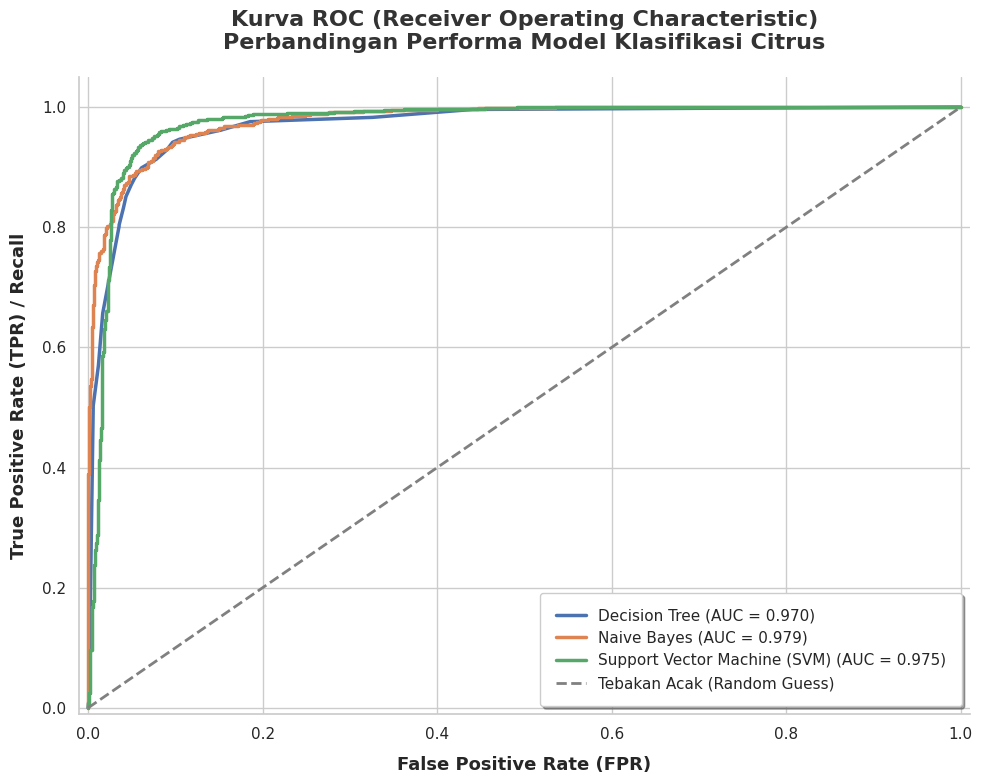

In [19]:
# 11. Visualisasi Kurva ROC (Receiver Operating Characteristic)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Membuat kanvas grafik
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Palet warna yang cukup untuk 6 model
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']

# Melakukan iterasi (perulangan) untuk setiap model guna menghitung nilai ROC
for (name, model), color in zip(models.items(), colors):

    # Mendapatkan nilai skor probabilitas untuk memprediksi kelas 1 (Grapefruit)
    # Pengecekan ini diperlukan karena SVM by default tidak menggunakan predict_proba
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_score = model.decision_function(X_test_scaled)

    # Menghitung False Positive Rate (FPR) dan True Positive Rate (TPR)
    fpr, tpr, thresholds = roc_curve(y_test, y_score)

    # Menghitung nilai Area Under the Curve (AUC)
    roc_auc = auc(fpr, tpr)

    # Menggambar garis kurva untuk masing-masing model
    plt.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC = {roc_auc:.3f})')

# Menggambar garis putus-putus diagonal (Tebakan Acak / Random Guess)
# Jika kurva model berada di bawah garis ini, berarti model lebih buruk dari tebakan koin
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Tebakan Acak (Random Guess)')

# Menambahkan detail teks, judul, dan penamaan sumbu
plt.title('Kurva ROC (Receiver Operating Characteristic)\nPerbandingan Performa Model Klasifikasi Citrus',
          fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.xlabel('False Positive Rate (FPR)', fontsize=13, fontweight='bold', labelpad=10)
plt.ylabel('True Positive Rate (TPR) / Recall', fontsize=13, fontweight='bold', labelpad=10)

# Mengatur batas sumbu X dan Y agar rapi (0.0 hingga 1.0)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.05])

# Menambahkan kotak Legenda di sudut kanan bawah
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True, borderpad=1)

# Membersihkan bingkai kanan dan atas
sns.despine()

# Menampilkan grafik
plt.tight_layout()
plt.show()